In [45]:
import torch
from pathlib import Path
import preprocess_data as ppd
from process_session import session as ss
import process_probe as pp
import numpy as np
from preprocess_data import *
from torch.utils.data import DataLoader, TensorDataset
import models as models
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score 

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Session obj contains stimulus, channel, and unit information
session_id = 1044385384
session_obj = ss(session_id)

c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.5.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."


In [4]:
# Spikes obj contains Spike matrix
bin_size=0.004
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
spikes_obj.convolve_with_gaussian()
spikes_obj.zscore()

100%|██████████| 741/741 [01:09<00:00, 10.62it/s]


In [16]:
# Probe obj contains LFP data
# Getting LFP just for active trials
import importlib
importlib.reload(pp)
probe_obj = pp.probe(session_obj, session_obj.active_times[0], session_obj.active_times[1])
lfp_obj = ppd.pre_process_lfp(probe_obj.lfp, 1250)
lfp_obj.filter_lfp(probe_obj.bands)
lfp_obj.downsample_lfp(5) # Downsample by 5
lfp_obj.align_lfp(spikes_obj.spkMat.shape[0])

c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.5.1 because version 1.8.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'core' version 2.5.0 because version 2.7.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
c:\Users\SB13FLPC018\miniconda3\envs\torch\lib\site-packages\hdmf\spec\namespace.py:535: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.2.0 because version 0.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
100%|██████████| 8/8 [03:36<00:00, 27.10s/it]


In [77]:
# get spontaneous data
spikes_obj_spont = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj_spont.getSpkMat(session_obj.spontaneous_times[0], session_obj.spontaneous_times[1])
spikes_obj_spont.convolve_with_gaussian()
spikes_obj_spont.zscore()

lfp_obj_spont = ppd.pre_process_lfp(probe_obj.lfp, 1250)
lfp_obj_spont.filter_lfp(probe_obj.bands)
lfp_obj_spont.downsample_lfp(5) # Downsample by 5
lfp_obj_spont.align_lfp(spikes_obj_spont.spkMat.shape[0])

100%|██████████| 8/8 [04:05<00:00, 30.71s/it]


In [92]:
print(lfp_obj_spont.lfpMat.shape)
print(spikes_obj_spont.spkMat.shape)

(72250, 20, 9)
(72250, 741)


In [18]:
# Training hyperparameters
input_size = spikes_obj.spkMat.shape[1]
hidden_size = 50 # temp value, don't have gpu so just to make sure everything works
num_layers = 1
seqlength = 750
num_epochs = 15 # temp value, just to make sure everything works w/o bugs

In [38]:
chani = 5 # deep layer
bandi = 0 # broadband

X_train, X_test, y_train, y_test = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi] , seqlength, test_size=0.2, random_state=42)

# Convert to PyTorch tensors and move to GPU
X_train = torch.from_numpy(X_train).float().to(device)
X_test = torch.from_numpy(X_test).float().to(device)
y_train = torch.from_numpy(y_train).float().to(device)
y_test = torch.from_numpy(y_test).float().to(device)

# Create DataLoader for batching
train_dataset = TensorDataset(X_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [41]:
# linear regression model 
linear_model = models.LinearRegressionModel(input_size)
ln_train_loss, ln_test_loss = linear_model.train(train_dataloader,
                                               test_dataloader, numepochs=1)

print(f'Linear regression train loss: {ln_train_loss[-1]:.4f}')
print(f'Linear regression test loss: {ln_test_loss[-1]:.4f}')

Linear regression train loss: 0.3433
Linear regression test loss: 0.5695


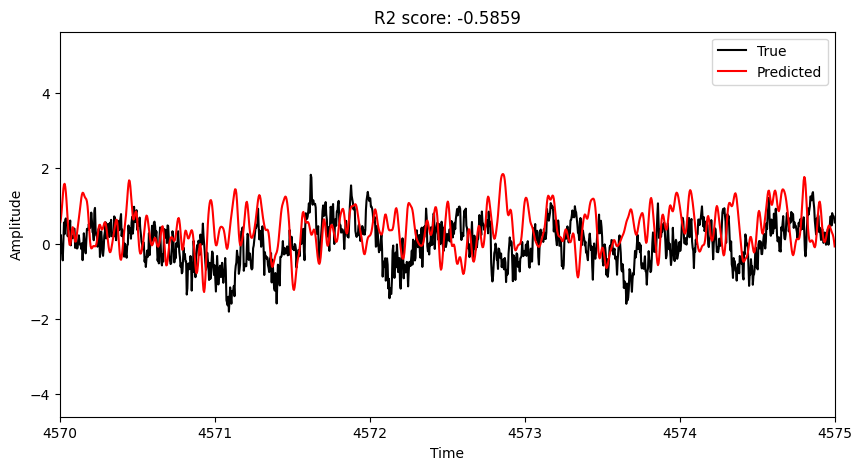

In [ ]:
# 3. Evaluate the linear model
test_spikes = torch.cat([X for X, _ in test_dataloader], dim=0)
test_lfp = torch.cat([y for _, y in test_dataloader], dim=0)

# reshape to time X features
test_spikes = test_spikes.reshape(test_spikes.shape[0] * test_spikes.shape[1], test_spikes.shape[2])
test_lfp = test_lfp.reshape(test_lfp.shape[0] * test_lfp.shape[1])
 
y_hat_test = linear_model.evaluate(test_spikes)

time_test = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time_test, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time_test, y_hat_test, 'r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()

y_hat_spont = linear_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, 'r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()


In [65]:
# LSTM model
criterion = torch.nn.MSELoss()
importlib.reload(models)
num_epochs = 15
lstm_model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

print(f'LSTM  train loss: {lstm_train_loss[-1]:.4f}')
print(f'LSTM  test loss: {lstm_test_loss[-1]:.4f}')

LSTM  train loss: 0.2108
LSTM  test loss: 0.3200


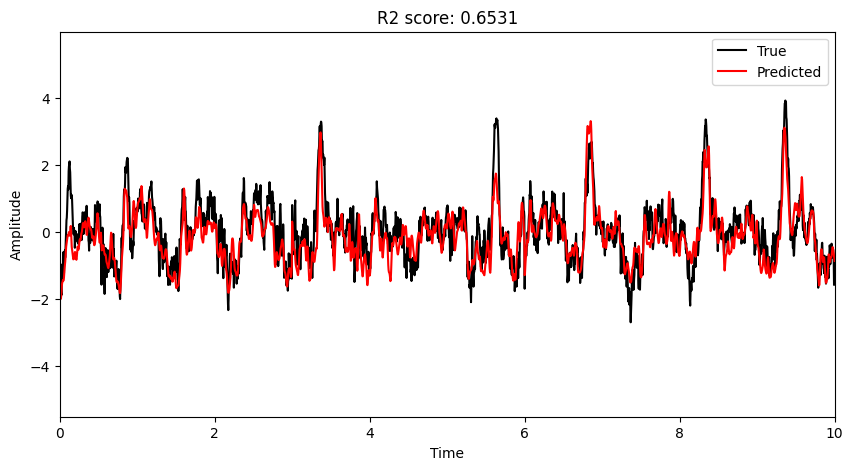

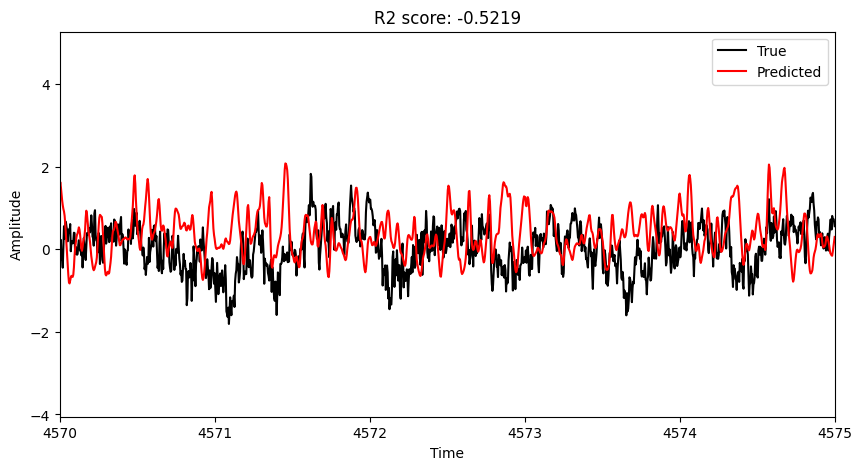

In [103]:
y_hat_test = lstm_model.evaluate(test_spikes)

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test, 'r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()

y_hat_spont = lstm_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float().to(device))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, 'r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,bandi], y_hat_spont):.4f}')
ax.legend()

In [71]:
# transformer model
importlib.reload(models)
num_epochs = 10
transformer_model = models.process_model(models.SpikingTransformer(input_size=input_size, seqlength=seqlength,
                                                                   embedding_dim = 32, num_heads = 4, 
                                                                   dropout=0.3), criterion, device)

transformer_train_loss, transformer_test_loss = transformer_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

print(f'transformer  train loss: {transformer_train_loss[-1]:.4f}')
print(f'transformer  test loss:  {transformer_test_loss[-1]:.4f}')

transformer  train loss: 0.3596
transformer  test loss:  0.3285


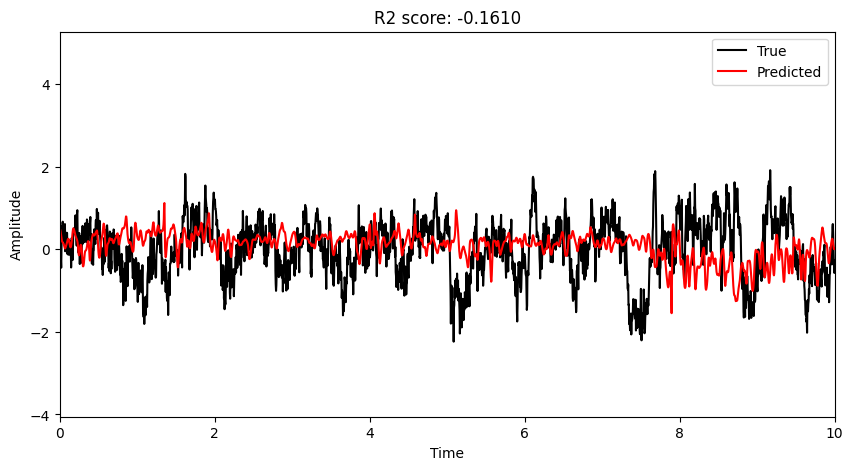

In [ ]:
y_hat_test = transformer_model.evaluate(test_spikes)

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test, 'r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test):.4f}')
ax.legend()

y_hat_spont = transformer_model.evaluate(torch.tensor(spikes_obj_spont.spkMat).float())

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj_spont.timestamps, lfp_obj_spont.lfpMat[:,chani,bandi], 'k', label='True')
ax.plot(spikes_obj_spont.timestamps, y_hat_spont, 'r', label='Predicted')
ax.set_xlim([spikes_obj_spont.timestamps[0], spikes_obj_spont.timestamps[0]+5])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(lfp_obj_spont.lfpMat[:,chani,0], y_hat_spont):.4f}')
ax.legend()